13. Classifying Cifar10 images using CNN


## Import Libraries

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

/Users/madams1/Documents/FAU/boilerplate/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


I start by creating a test dict of names, and next iterate through the plots to create my tensor boilderplate

Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


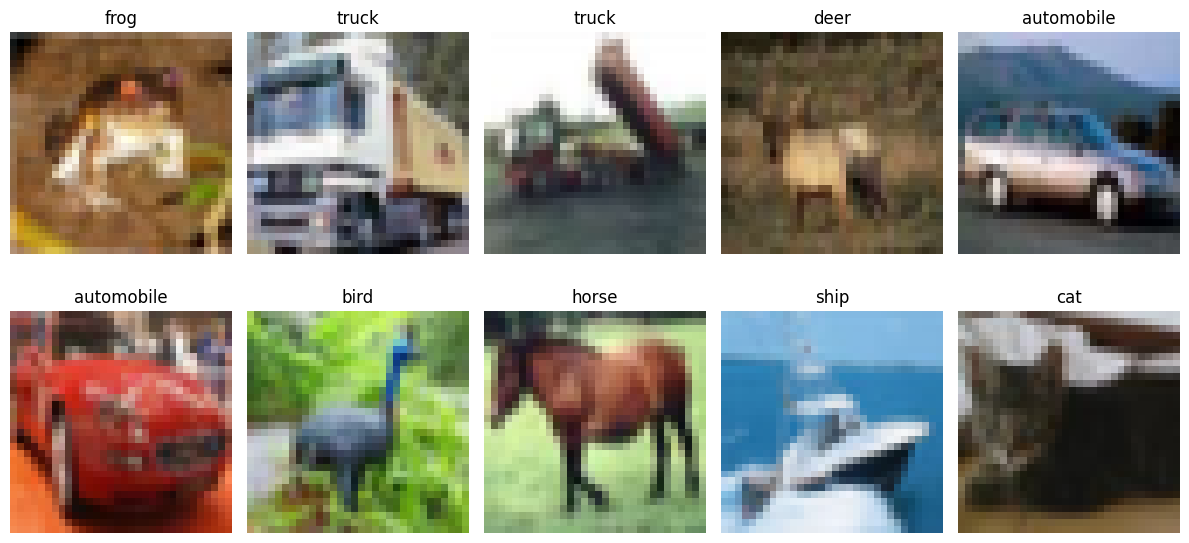

In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()


print(f"Training images shape: {x_train.shape}")  # (50000, 32, 32, 3)
print(f"Training labels shape: {y_train.shape}")  # (50000, 1)
print(f"Test images shape: {x_test.shape}")        # (10000, 32, 32, 3)
print(f"Test labels shape: {y_test.shape}")        # (10000, 1)


class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()

Next, I print the code to persue the preprocessing data the same to see my trainign shape and have an idea what what is needed to transform

In [3]:
# Normalize pixel values from [0, 255] to [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Convert to one-hot encoding
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test  = keras.utils.to_categorical(y_test, num_classes)

print(f"After one-hot encoding:")
print(f"y_train shape: {y_train.shape}")  # (50000, 10)
print(f"y_test shape: {y_test.shape}")    # (10000, 10)

After one-hot encoding:
y_train shape: (50000, 10)
y_test shape: (10000, 10)


then i iterate through an array of sample images and apply random transformations  (this is to improve model transformation) and apply my findings to the gui 

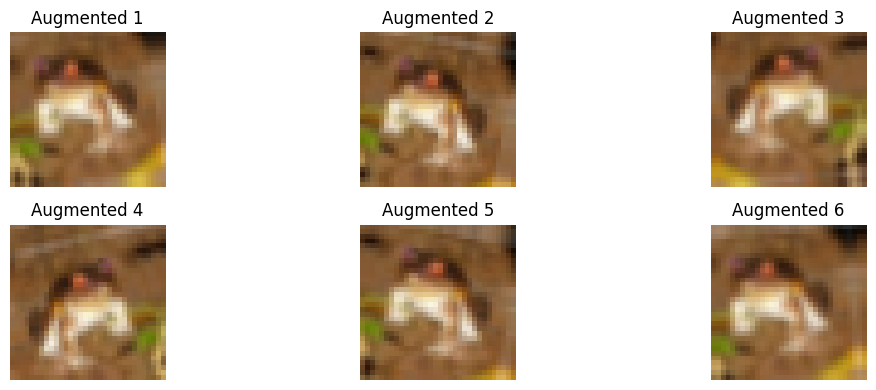

In [4]:
# Create data augmentation pipeline
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),          # Flip images left-right
    layers.RandomTranslation(0.1, 0.1),       # Shift images by 10%
    layers.RandomRotation(0.05),              # Rotate by ±5%
])

# Visualize augmented images
plt.figure(figsize=(12, 4))
sample_img = x_train[0:1]  #
for i in range(6):
    plt.subplot(2, 3, i + 1)
    augmented = data_aug(sample_img, training=True)
    plt.imshow(augmented[0])
    plt.title(f'Augmented {i+1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

the CNN architecture remains the same:

In [7]:
# Build CNN using Functional API
inputs = keras.Input(shape=(32, 32, 3))
x = data_aug(inputs)

# Block 1: 32 filters
x = layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
x = layers.ReLU()(x)
x = layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
x = layers.ReLU()(x)

# Block 2: 64 filters
x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
x = layers.ReLU()(x)
x = layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
x = layers.ReLU()(x)

# Block 3: 128 filters
x = layers.Conv2D(128, 3, padding="same", use_bias=False)(x)
x = layers.ReLU()(x)
x = layers.Conv2D(128, 3, padding="same", use_bias=False)(x)
x = layers.ReLU()(x)

# Classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

but here i just add a simple in-built summary function to the model

In [8]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304,362 (1.16 MB)

 Trainable params: 304,362 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

and then also use the compile function to build the model, adding the adam optimizer (and loss and metrics for multi class classification and accurancy)

In [9]:
# === WHAT WAS ADDED ===
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


another function, this time the fit() function, adding the params, including applying 128 batch size and 20 epochs (which eneded up taking a lot longer than i anticipated on my machine to render)

In [ ]:

history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=20,
    validation_split=0.1,
    verbose=1
)

training hisotry validation

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


then i uncommented line 76 to execute the eveluate function

In [10]:

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

Test accuracy: 0.0836
Test loss: 2.3026



Now we can make predictions using sample images!

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


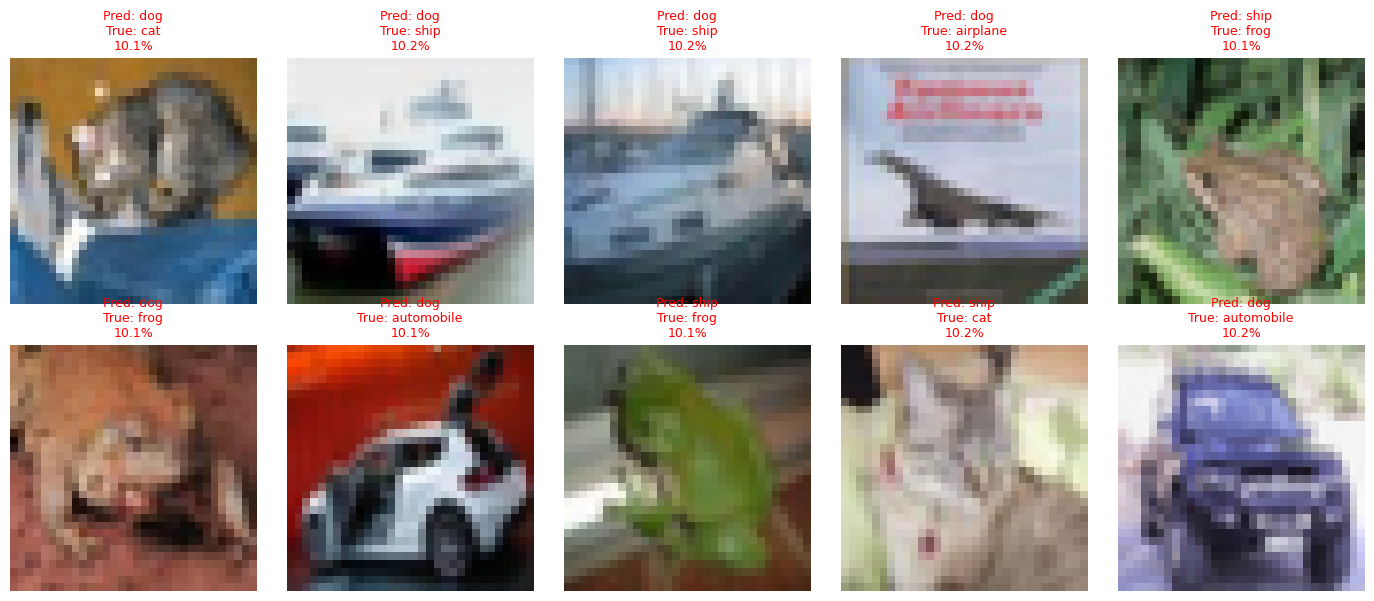

In [ ]:

predictions = model.predict(x_test[:10])
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test[:10], axis=1)

plt.figure(figsize=(14, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i])
    
    pred_class = class_names[predicted_classes[i]]
    true_class = class_names[true_classes[i]]
    confidence = predictions[i][predicted_classes[i]] * 100
    
    color = 'green' if predicted_classes[i] == true_classes[i] else 'red'
    plt.title(f'Pred: {pred_class}\nTrue: {true_class}\n{confidence:.1f}%', 
              color=color, fontsize=9)
    plt.axis('off')
    
plt.tight_layout()
plt.show()